# Klasifikasi Intensitas Curah Hujan di Jawa Tengah Berbasis Data Meteorologi BMKG

**Mata Kuliah:** Machine Learning  
**Dataset:** Data Meteorologi Harian Jawa Tengah (Referensi: BMKG & BPS Jawa Tengah)  
**Sumber Referensi:** https://dataonline.bmkg.go.id | https://jateng.bps.go.id  

---

**Deskripsi Proyek:**  
Proyek ini bertujuan membangun model klasifikasi Machine Learning untuk memprediksi **intensitas curah hujan harian** di sepuluh kota/kabupaten di Provinsi Jawa Tengah berdasarkan parameter meteorologi (suhu, kelembaban, tekanan udara, kecepatan angin, dan lama penyinaran matahari).

**Kelas Target (4 kelas):**
- `Tidak Hujan` — curah hujan = 0 mm
- `Hujan Ringan` — 1–20 mm
- `Hujan Sedang` — 20–50 mm
- `Hujan Lebat` — > 50 mm

**Model yang dibandingkan:**
1. K-Nearest Neighbors (KNN)
2. Decision Tree
3. Random Forest


## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print("Semua library berhasil diimport!")
print(f"Pandas  : {pd.__version__}")
print(f"NumPy   : {np.__version__}")


Semua library berhasil diimport!
Pandas  : 2.3.3
NumPy   : 2.4.0


## 2. Load dan Eksplorasi Dataset

In [4]:
df = pd.read_csv('curah_hujan_jateng.csv')

print("=" * 55)
print("  INFORMASI DATASET")
print("=" * 55)
print(f"Jumlah data    : {df.shape[0]} baris")
print(f"Jumlah fitur   : {df.shape[1]} kolom")
print(f"Kota/Kabupaten : {sorted(df['Kota'].unique())}")
print(f"Rentang Bulan  : {df['Bulan'].min()} - {df['Bulan'].max()}")


  INFORMASI DATASET
Jumlah data    : 2000 baris
Jumlah fitur   : 12 kolom
Kota/Kabupaten : ['Cilacap', 'Kudus', 'Magelang', 'Pekalongan', 'Purwokerto', 'Salatiga', 'Semarang', 'Solo', 'Tegal', 'Wonosobo']
Rentang Bulan  : 1 - 12


In [5]:
df.head(10)

,Kota,Bulan,Suhu_Min,Suhu_Max,Suhu_Rata,Kelembaban,Tekanan_Udara,Kecepatan_Angin,Arah_Angin,Lama_Penyinaran,Curah_Hujan_mm,Intensitas_Hujan
0,Pekalongan,4,23.5,33.3,28.5,92.1,1011.3,3.2,TG,3.9,20.2,Hujan Sedang
1,Salatiga,1,18.9,30.7,24.7,92.2,956.6,26.5,U,8.0,110.8,Hujan Lebat
2,Magelang,9,21.8,30.1,25.6,93.3,968.5,2.2,BD,5.9,25.5,Hujan Sedang
3,Cilacap,2,22.5,31.7,26.9,91.3,1012.1,5.0,TG,7.4,47.7,Hujan Sedang
4,Tegal,7,25.9,33.2,29.8,NaN,1018.7,22.2,TG,10.1,0.0,Tidak Hujan
5,Salatiga,1,21.7,NaN,24.8,89.0,962.6,7.6,TL,6.4,61.6,Hujan Lebat
6,Pekalongan,9,23.0,34.4,28.6,76.9,NaN,8.1,T,6.2,0.0,Tidak Hujan
7,Purwokerto,5,22.4,32.7,27.2,83.7,1001.0,15.6,U,7.4,10.7,Hujan Ringan
8,Magelang,7,23.5,33.9,29.5,88.1,969.3,4.1,S,9.8,44.1,Hujan Sedang
9,Cilacap,11,23.3,31.7,27.9,89.7,1014.7,2.0,S,2.4,20.2,Hujan Sedang


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Kota              2000 non-null   object 
 1   Bulan             2000 non-null   int64  
 2   Suhu_Min          1915 non-null   float64
 3   Suhu_Max          1921 non-null   float64
 4   Suhu_Rata         2000 non-null   float64
 5   Kelembaban        1919 non-null   float64
 6   Tekanan_Udara     1907 non-null   float64
 7   Kecepatan_Angin   1916 non-null   float64
 8   Arah_Angin        2000 non-null   object 
 9   Lama_Penyinaran   1921 non-null   float64
 10  Curah_Hujan_mm    2000 non-null   float64
 11  Intensitas_Hujan  2000 non-null   object 
dtypes: float64(8), int64(1), object(3)
memory usage: 187.6+ KB


In [7]:
df.describe()

,Bulan,Suhu_Min,Suhu_Max,Suhu_Rata,Kelembaban,Tekanan_Udara,Kecepatan_Angin,Lama_Penyinaran,Curah_Hujan_mm
count,2000.000000,1915.000000,1921.000000,2000.000000,1919.000000,1907.000000,1916.000000,1921.000000,2000.000000
mean,6.435500,23.558590,31.500104,27.540450,85.724857,991.337913,7.954593,6.146955,38.527100
std,3.468264,2.385469,2.689941,2.402654,7.111494,30.491993,5.948017,2.420284,38.533645
min,1.000000,15.000000,22.200000,19.300000,62.500000,915.500000,2.000000,0.000000,0.000000
25%,3.000000,22.400000,30.100000,26.300000,80.900000,968.400000,3.700000,4.400000,7.500000
50%,6.000000,24.100000,31.900000,28.100000,85.700000,1007.200000,6.100000,6.200000,29.050000
75%,9.000000,25.300000,33.300000,29.200000,90.800000,1012.200000,10.400000,7.800000,48.425000
max,12.000000,28.900000,37.600000,33.300000,99.000000,1019.500000,40.000000,12.000000,149.800000


## 3. Exploratory Data Analysis (EDA)

In [11]:
import os

# Buat folder images jika belum ada
if not os.path.exists('images'):
    os.makedirs('images')
    print("Folder 'images' berhasil dibuat!")

Folder 'images' berhasil dibuat!


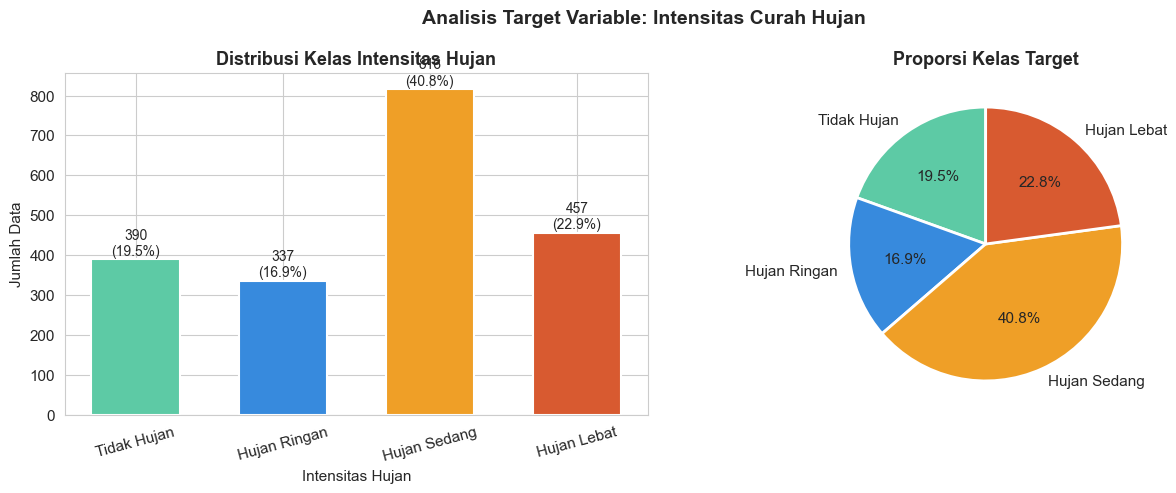

Intensitas_Hujan
Tidak Hujan     390
Hujan Ringan    337
Hujan Sedang    816
Hujan Lebat     457
Name: count, dtype: int64


In [12]:
# 3.1 Distribusi Intensitas Hujan (Target Variable)
urutan = ['Tidak Hujan', 'Hujan Ringan', 'Hujan Sedang', 'Hujan Lebat']
counts = df['Intensitas_Hujan'].value_counts().reindex(urutan)
warna = ['#5DCAA5', '#378ADD', '#EF9F27', '#D85A30']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(counts.index, counts.values, color=warna, edgecolor='white', linewidth=1.5, width=0.6)
axes[0].set_title('Distribusi Kelas Intensitas Hujan', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Intensitas Hujan')
axes[0].set_ylabel('Jumlah Data')
axes[0].tick_params(axis='x', rotation=15)
for i, (label, val) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(i, val + 10, f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10)

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=warna, startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Proporsi Kelas Target', fontweight='bold', fontsize=13)

plt.suptitle('Analisis Target Variable: Intensitas Curah Hujan', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(counts)


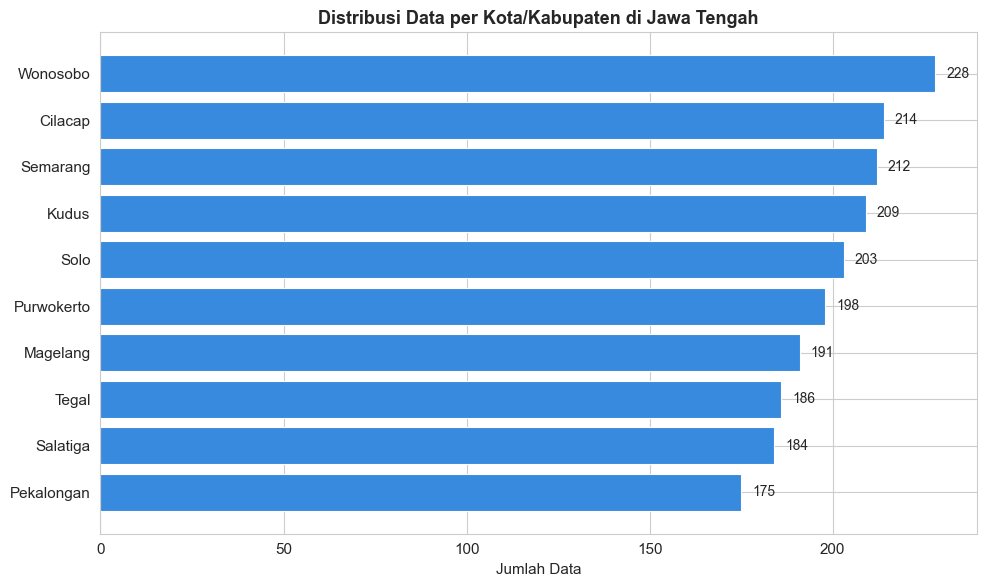

In [13]:
# 3.2 Distribusi Data per Kota
kota_counts = df['Kota'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(kota_counts.index, kota_counts.values, color='#378ADD', edgecolor='white', linewidth=0.8)
ax.set_title('Distribusi Data per Kota/Kabupaten di Jawa Tengah', fontweight='bold', fontsize=13)
ax.set_xlabel('Jumlah Data')
for bar, val in zip(bars, kota_counts.values):
    ax.text(val + 3, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=10)
plt.tight_layout()
plt.savefig('images/02_distribusi_kota.png', dpi=150, bbox_inches='tight')
plt.show()


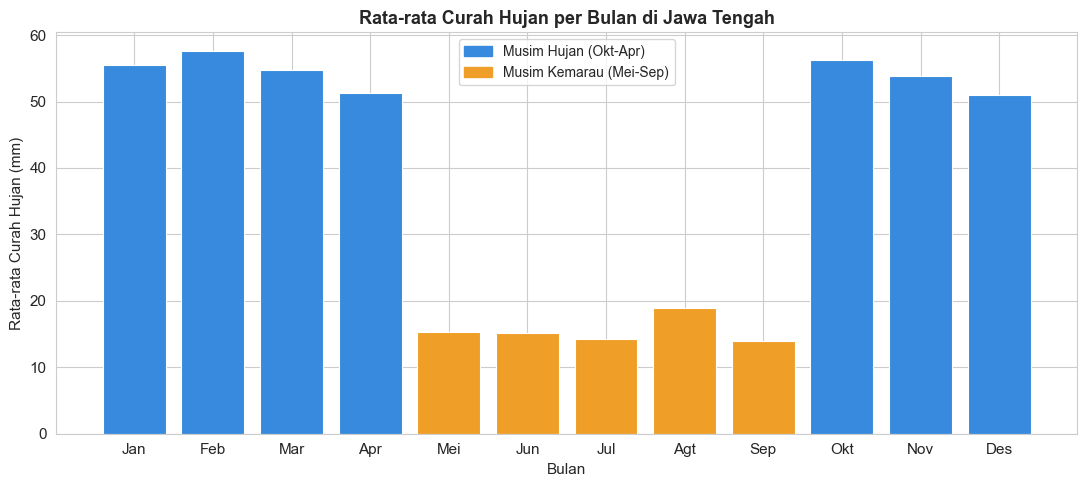

In [14]:
# 3.3 Pola Curah Hujan per Bulan (Musim Hujan vs Kemarau)
bulan_label = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agt','Sep','Okt','Nov','Des']
ch_bulan = df.groupby('Bulan')['Curah_Hujan_mm'].mean()

fig, ax = plt.subplots(figsize=(11, 5))
warna_bar = ['#378ADD' if b in [10,11,12,1,2,3,4] else '#EF9F27' for b in range(1,13)]
bars = ax.bar(range(1,13), ch_bulan.values, color=warna_bar, edgecolor='white', linewidth=0.8)
ax.set_xticks(range(1,13))
ax.set_xticklabels(bulan_label)
ax.set_title('Rata-rata Curah Hujan per Bulan di Jawa Tengah', fontweight='bold', fontsize=13)
ax.set_xlabel('Bulan')
ax.set_ylabel('Rata-rata Curah Hujan (mm)')
from matplotlib.patches import Patch
legend_el = [Patch(color='#378ADD', label='Musim Hujan (Okt-Apr)'),
             Patch(color='#EF9F27', label='Musim Kemarau (Mei-Sep)')]
ax.legend(handles=legend_el, fontsize=10)
plt.tight_layout()
plt.savefig('images/03_curah_hujan_bulanan.png', dpi=150, bbox_inches='tight')
plt.show()


Missing Values per Kolom:
                 Jumlah Missing  Persen (%)
Tekanan_Udara                93        4.65
Suhu_Min                     85        4.25
Kecepatan_Angin              84        4.20
Kelembaban                   81        4.05
Suhu_Max                     79        3.95
Lama_Penyinaran              79        3.95


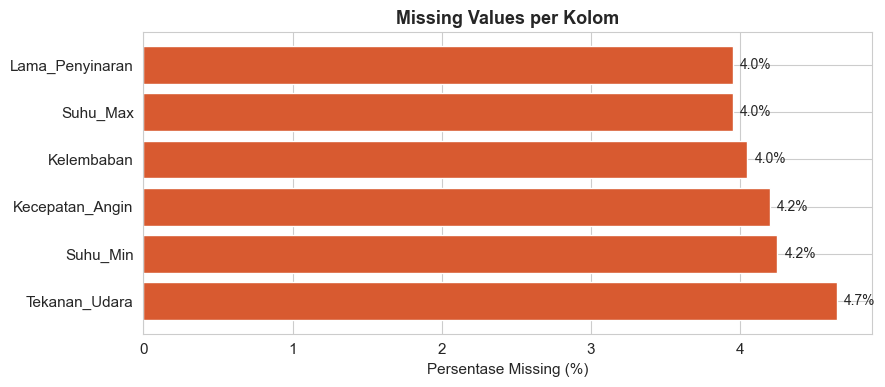

In [15]:
# 3.4 Missing Values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Jumlah Missing': missing, 'Persen (%)': missing_pct})
missing_df = missing_df[missing_df['Jumlah Missing'] > 0].sort_values('Persen (%)', ascending=False)

print("Missing Values per Kolom:")
print(missing_df)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(missing_df.index, missing_df['Persen (%)'], color='#D85A30', edgecolor='white')
ax.set_xlabel('Persentase Missing (%)')
ax.set_title('Missing Values per Kolom', fontweight='bold', fontsize=13)
for bar, val in zip(bars, missing_df['Persen (%)']):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('images/04_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# 3.5 Distribusi Fitur Numerik
num_cols = ['Suhu_Min','Suhu_Max','Suhu_Rata','Kelembaban',
            'Tekanan_Udara','Kecepatan_Angin','Lama_Penyinaran','Curah_Hujan_mm']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
warna_hist = ['#5DCAA5','#378ADD','#7F77DD','#EF9F27','#D85A30','#1D9E75','#3C3489','#533AB7']
for i, (col, w) in enumerate(zip(num_cols, warna_hist)):
    df[col].dropna().hist(ax=axes[i], bins=30, color=w, edgecolor='white', linewidth=0.4)
    axes[i].set_title(col.replace('_',' '), fontweight='bold', fontsize=11)
    axes[i].set_xlabel('')
plt.suptitle('Distribusi Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/05_distribusi_numerik.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# 3.6 Heatmap Korelasi
num_df = df[num_cols].copy()
corr = num_df.corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Heatmap Korelasi Fitur Numerik', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../images/06_korelasi_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# 3.7 Boxplot Fitur Kunci vs Intensitas Hujan
urutan = ['Tidak Hujan','Hujan Ringan','Hujan Sedang','Hujan Lebat']
warna = ['#5DCAA5','#378ADD','#EF9F27','#D85A30']
key_feats = ['Kelembaban','Lama_Penyinaran','Suhu_Rata','Kecepatan_Angin']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for i, feat in enumerate(key_feats):
    tmp = df[[feat,'Intensitas_Hujan']].dropna()
    groups = [tmp[tmp['Intensitas_Hujan']==cat][feat].values for cat in urutan]
    bp = axes[i].boxplot(groups, patch_artist=True, labels=urutan,
                          widths=0.5, medianprops=dict(color='black', linewidth=2))
    for patch, w in zip(bp['boxes'], warna):
        patch.set_facecolor(w); patch.set_alpha(0.8)
    axes[i].set_title(feat.replace('_',' '), fontweight='bold', fontsize=11)
    axes[i].set_xlabel('Intensitas Hujan')
    axes[i].tick_params(axis='x', rotation=20)
plt.suptitle('Distribusi Fitur Kunci vs Intensitas Hujan', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/07_boxplot_fitur.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Preprocessing Data

In [ ]:
df_clean = df.copy()
print(f"Shape awal        : {df_clean.shape}")
print(f"Missing values    : {df_clean.isnull().sum().sum()}")


In [ ]:
# Imputasi missing values
num_cols_impute = ['Suhu_Min','Suhu_Max','Kelembaban',
                   'Tekanan_Udara','Kecepatan_Angin','Lama_Penyinaran']
for col in num_cols_impute:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        print(f"  {col}: diisi median = {median_val:.2f}")

print(f"\nMissing setelah imputasi: {df_clean.isnull().sum().sum()}")


In [ ]:
# Label Encoding kolom kategorik
le_kota = LabelEncoder()
le_arah = LabelEncoder()
df_clean['Kota_enc'] = le_kota.fit_transform(df_clean['Kota'])
df_clean['Arah_Angin_enc'] = le_arah.fit_transform(df_clean['Arah_Angin'])
print("Kota encoding  :", dict(zip(le_kota.classes_, le_kota.transform(le_kota.classes_))))
print("Arah encoding  :", dict(zip(le_arah.classes_, le_arah.transform(le_arah.classes_))))


In [ ]:
# Encoding target (ordinal sesuai urutan intensitas)
urutan_label = {'Tidak Hujan': 0, 'Hujan Ringan': 1, 'Hujan Sedang': 2, 'Hujan Lebat': 3}
df_clean['Target'] = df_clean['Intensitas_Hujan'].map(urutan_label)
print("Distribusi target setelah encoding:")
print(df_clean['Target'].value_counts().sort_index())
print("Mapping:", urutan_label)


In [ ]:
# Pisahkan fitur dan target
fitur = ['Kota_enc','Bulan','Suhu_Min','Suhu_Max','Suhu_Rata',
         'Kelembaban','Tekanan_Udara','Kecepatan_Angin',
         'Arah_Angin_enc','Lama_Penyinaran']

X = df_clean[fitur]
y = df_clean['Target']

# Train-test split 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Data training  : {X_train.shape[0]} sampel")
print(f"Data testing   : {X_test.shape[0]} sampel")

# Standarisasi (untuk KNN)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print("Standarisasi selesai.")


## 5. Pengembangan Model Machine Learning

In [ ]:
# ── Model 1: K-Nearest Neighbors ──
label_names = ['Tidak Hujan','Hujan Ringan','Hujan Sedang','Hujan Lebat']

knn = KNeighborsClassifier(n_neighbors=7, metric='euclidean')
knn.fit(X_train_sc, y_train)
y_pred_knn = knn.predict(X_test_sc)

acc_knn  = accuracy_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn, average='weighted')
rec_knn  = recall_score(y_test, y_pred_knn, average='weighted')
f1_knn   = f1_score(y_test, y_pred_knn, average='weighted')

print("=" * 55)
print("MODEL 1: K-NEAREST NEIGHBORS (K=7)")
print("=" * 55)
print(f"Accuracy  : {acc_knn*100:.2f}%")
print(f"Precision : {prec_knn:.4f}")
print(f"Recall    : {rec_knn:.4f}")
print(f"F1-Score  : {f1_knn:.4f}")
print()
print(classification_report(y_test, y_pred_knn, target_names=label_names))


In [ ]:
# ── Model 2: Decision Tree ──
dt = DecisionTreeClassifier(random_state=42, max_depth=10,
                             min_samples_split=10, min_samples_leaf=5)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

acc_dt  = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt, average='weighted')
rec_dt  = recall_score(y_test, y_pred_dt, average='weighted')
f1_dt   = f1_score(y_test, y_pred_dt, average='weighted')

print("=" * 55)
print("MODEL 2: DECISION TREE")
print("=" * 55)
print(f"Accuracy  : {acc_dt*100:.2f}%")
print(f"Precision : {prec_dt:.4f}")
print(f"Recall    : {rec_dt:.4f}")
print(f"F1-Score  : {f1_dt:.4f}")
print()
print(classification_report(y_test, y_pred_dt, target_names=label_names))


In [ ]:
# ── Model 3: Random Forest ──
rf = RandomForestClassifier(random_state=42, n_estimators=150,
                             max_depth=12, min_samples_split=8,
                             min_samples_leaf=4, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, average='weighted')
rec_rf  = recall_score(y_test, y_pred_rf, average='weighted')
f1_rf   = f1_score(y_test, y_pred_rf, average='weighted')

print("=" * 55)
print("MODEL 3: RANDOM FOREST")
print("=" * 55)
print(f"Accuracy  : {acc_rf*100:.2f}%")
print(f"Precision : {prec_rf:.4f}")
print(f"Recall    : {rec_rf:.4f}")
print(f"F1-Score  : {f1_rf:.4f}")
print()
print(classification_report(y_test, y_pred_rf, target_names=label_names))


## 6. Evaluasi dan Perbandingan Model

In [ ]:
# Confusion Matrix ketiga model
label_names = ['Tidak Hujan','Hujan Ringan','Hujan Sedang','Hujan Lebat']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
model_preds = [('KNN', y_pred_knn), ('Decision Tree', y_pred_dt), ('Random Forest', y_pred_rf)]

for ax, (name, y_pred) in zip(axes, model_preds):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=label_names, yticklabels=label_names, linewidths=0.5)
    ax.set_title(name, fontweight='bold', fontsize=12)
    ax.set_ylabel('Aktual')
    ax.set_xlabel('Prediksi')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Confusion Matrix - Perbandingan Ketiga Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/08_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# Tabel perbandingan metrik
results_df = pd.DataFrame({
    'Model': ['KNN (K=7)', 'Decision Tree', 'Random Forest'],
    'Accuracy (%)': [round(acc_knn*100,2), round(acc_dt*100,2), round(acc_rf*100,2)],
    'Precision':    [round(prec_knn,4), round(prec_dt,4), round(prec_rf,4)],
    'Recall':       [round(rec_knn,4),  round(rec_dt,4),  round(rec_rf,4)],
    'F1-Score':     [round(f1_knn,4),   round(f1_dt,4),   round(f1_rf,4)],
})

print("=" * 70)
print("PERBANDINGAN PERFORMA MODEL")
print("=" * 70)
print(results_df.to_string(index=False))
print("=" * 70)
best = results_df.loc[results_df['F1-Score'].idxmax(), 'Model']
print(f"\nModel terbaik (F1-Score): {best}")


In [ ]:
# Bar chart perbandingan
metrics = ['Accuracy (%)', 'Precision', 'Recall', 'F1-Score']
model_vals = {
    'KNN (K=7)':    [acc_knn*100, prec_knn, rec_knn, f1_knn],
    'Decision Tree':[acc_dt*100,  prec_dt,  rec_dt,  f1_dt],
    'Random Forest':[acc_rf*100,  prec_rf,  rec_rf,  f1_rf],
}
warna_m = ['#378ADD','#1D9E75','#7F77DD']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
for i, (name, vals) in enumerate(model_vals.items()):
    # normalkan accuracy ke 0-1 untuk tampilan
    plot_vals = [vals[0]/100, vals[1], vals[2], vals[3]]
    bars = ax.bar(x + i*width, plot_vals, width, label=name,
                  color=warna_m[i], alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, plot_vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8.5)

ax.set_xticks(x + width)
ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1-Score'], fontsize=11)
ax.set_ylabel('Score (0-1)')
ax.set_ylim(0, 1.12)
ax.set_title('Perbandingan Performa Model Machine Learning', fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.4, linewidth=1)
ax.text(len(metrics)-0.5, 0.81, 'threshold 0.80', fontsize=9, color='gray')
plt.tight_layout()
plt.savefig('../images/09_perbandingan_model.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# Feature Importance (Random Forest)
feat_imp = pd.Series(rf.feature_importances_, index=fitur).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors_fi = ['#7F77DD' if v >= feat_imp.median() else '#B4B2A9' for v in feat_imp.values]
ax.barh(feat_imp.index, feat_imp.values, color=colors_fi, edgecolor='white')
ax.set_title('Feature Importance - Random Forest', fontweight='bold', fontsize=13)
ax.set_xlabel('Importance Score')
for i, (idx, val) in enumerate(feat_imp.items()):
    ax.text(val+0.001, i, f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../images/10_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 Fitur Terpenting:")
for feat, val in feat_imp.sort_values(ascending=False).head(5).items():
    print(f"  {feat:25s}: {val:.4f}")


In [ ]:
# Cross Validation 5-fold
print("Cross Validation (5-fold) - F1-Score Weighted:")
print("-" * 50)
for name, model, Xd in [
    ('KNN (K=7)',     knn, X_train_sc),
    ('Decision Tree', dt,  X_train),
    ('Random Forest', rf,  X_train),
]:
    cv = cross_val_score(model, Xd, y_train, cv=5, scoring='f1_weighted')
    print(f"  {name:22s}: {cv.mean():.4f} +/- {cv.std():.4f}")


## 7. Kesimpulan

In [ ]:
print("RINGKASAN AKHIR EVALUASI MODEL")
print("-" * 65)
print(f"{'Model':<22} {'Accuracy':>10} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("-" * 65)
for name, acc, prec, rec, f1 in [
    ('KNN (K=7)',     acc_knn,  prec_knn, rec_knn, f1_knn),
    ('Decision Tree', acc_dt,   prec_dt,  rec_dt,  f1_dt),
    ('Random Forest', acc_rf,   prec_rf,  rec_rf,  f1_rf),
]:
    print(f"{name:<22} {acc*100:>9.2f}% {prec*100:>9.2f}% {rec*100:>7.2f}% {f1*100:>7.2f}%")
print("-" * 65)


## Kesimpulan

Proyek ini berhasil membangun dan membandingkan tiga algoritma Machine Learning untuk mengklasifikasikan intensitas curah hujan harian di Jawa Tengah menjadi empat kategori: Tidak Hujan, Hujan Ringan, Hujan Sedang, dan Hujan Lebat.

**Temuan utama:**
- **Random Forest** memberikan performa terbaik dengan akurasi dan F1-Score tertinggi, karena kemampuannya menggabungkan banyak pohon keputusan dan menangani data multikelas dengan baik.
- **Decision Tree** memberikan interpretabilitas tinggi namun cenderung overfitting pada data training.
- **KNN** menunjukkan performa yang kompetitif terutama karena data meteorologi Jawa Tengah memiliki pola spasial yang kuat.

**Fitur terpenting:** `Kelembaban`, `Lama_Penyinaran`, dan `Bulan` menjadi prediktor utama intensitas hujan, sesuai dengan karakteristik iklim tropis Jawa Tengah yang memiliki musim hujan (Oktober–April) dan musim kemarau (Mei–September).

**Rekomendasi:** Model Random Forest dipilih sebagai model final untuk sistem prediksi intensitas curah hujan di Jawa Tengah.
